# Prática 5 de Aprendizado Supervisionado com Arvores de Decisão



### **Questão 1** Modifique o exemplo abaixo para 1000 amostras, dispersão 1.3 e observe a diferença visual das três técnicas: Árvores, KNN e Naive Bayes

In [ ]:
#@title Comparando Knn, Naive Bayes e Arvores (3 atributos, gráficos 2D pares) - **Modifique para 1000 amostras e dispersão 1.3**
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from ipywidgets import widgets
from IPython.display import display, clear_output
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Variáveis globais
X = None
y = None
X_train = None
X_test = None
y_train = None
y_test = None
accuracy = None
classifier = None
output_widget = widgets.Output()

# Criar widgets
classifier_selector = widgets.Dropdown(
    options=['KNN', 'Naive Bayes', 'Decision Tree'],
    value='KNN',
    description='Classificador:'
)
k_slider = widgets.IntSlider(min=1, max=15, value=3, description='K:')
n_samples_slider = widgets.IntSlider(min=10, max=200, value=100, description='Amostras:')
spread_slider = widgets.FloatSlider(min=0.5, max=5.0, value=2.0, step=0.1, description='Dispersão:')
test_size_slider = widgets.FloatSlider(min=0.1, max=0.5, value=0.2, step=0.05, description='% Teste:')
predict_button = widgets.Button(description='Avaliar Modelo')
new_data_button = widgets.Button(description='Gerar Novo Dataset')

controls_top = widgets.HBox([classifier_selector, k_slider, n_samples_slider, spread_slider, test_size_slider])
controls_bottom = widgets.HBox([predict_button, new_data_button])

def generate_dataset():
    global X, y, X_train, X_test, y_train, y_test
    n_samples = n_samples_slider.value
    spread = spread_slider.value
    test_size = test_size_slider.value

    # Gerar dados com 3 atributos
    X, y = make_blobs(n_samples=n_samples, centers=2, n_features=3,
                      cluster_std=spread, center_box=(-4, 4), random_state=None)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )
    return X_train, X_test, y_train, y_test

def create_classifier():
    global classifier
    if classifier_selector.value == 'KNN':
        classifier = KNeighborsClassifier(n_neighbors=k_slider.value)
    elif classifier_selector.value == 'Naive Bayes':
        classifier = GaussianNB()
    elif classifier_selector.value == 'Decision Tree':
        classifier = DecisionTreeClassifier()

def plot_decision_regions():
    global classifier
    with output_widget:
        clear_output(wait=True)
        plt.figure(figsize=(16, 5))

        if classifier is None:
            create_classifier()
            classifier.fit(X_train, y_train)

        # Três pares de atributos
        pairs = [(0,1), (0,2), (1,2)]
        titles = ["Atributos (X0 vs X1)", "Atributos (X0 vs X2)", "Atributos (X1 vs X2)"]

        for idx, (i, j) in enumerate(pairs):
            plt.subplot(1, 3, idx+1)

            # grid para regiões de decisão
            x_min, x_max = X[:, i].min() - 1, X[:, i].max() + 1
            y_min, y_max = X[:, j].min() - 1, X[:, j].max() + 1
            xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                                 np.arange(y_min, y_max, 0.1))

            Z = classifier.predict(np.c_[xx.ravel(), yy.ravel(),
                                         np.full(xx.ravel().shape, X[:, 3-i-j].mean())])
            # Observação: colocamos o 3º atributo fixo na média
            Z = Z.reshape(xx.shape)

            plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
            plt.contour(xx, yy, Z, cmap=plt.cm.RdYlBu)

            # pontos treino
            plt.scatter(X_train[y_train==0, i], X_train[y_train==0, j],
                        c='blue', marker='o', label='Classe 0 (Treino)')
            plt.scatter(X_train[y_train==1, i], X_train[y_train==1, j],
                        c='red', marker='o', label='Classe 1 (Treino)')
            # pontos teste
            plt.scatter(X_test[y_test==0, i], X_test[y_test==0, j],
                        c='lightblue', marker='s', label='Classe 0 (Teste)')
            plt.scatter(X_test[y_test==1, i], X_test[y_test==1, j],
                        c='lightcoral', marker='s', label='Classe 1 (Teste)')

            plt.title(titles[idx])
            plt.grid(True)

        if accuracy is not None:
            plt.suptitle(f"Acurácia: {accuracy:.2%} | "
                         f"Classificador: {classifier_selector.value}, "
                         f"K={k_slider.value if classifier_selector.value=='KNN' else 'N/A'}")

        plt.tight_layout()
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.show()

def make_prediction(b):
    global accuracy
    if X_train is None:
        generate_new_data(None)
        return
    create_classifier()
    classifier.fit(X_train, y_train)
    y_pred = classifier.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    plot_decision_regions()

def generate_new_data(b):
    generate_dataset()
    plot_decision_regions()

def update_k(change):
    if X_train is not None and classifier_selector.value == 'KNN':
        make_prediction(None)

def update_params(change):
    if X is not None:
        generate_new_data(None)

predict_button.on_click(make_prediction)
new_data_button.on_click(generate_new_data)
k_slider.observe(update_k, names='value')
classifier_selector.observe(update_k, names='value')
n_samples_slider.observe(update_params, names='value')
spread_slider.observe(update_params, names='value')
test_size_slider.observe(update_params, names='value')

display(controls_top)
display(controls_bottom)
display(output_widget)

# dataset inicial
generate_new_data(None)


Output()

### **Tarefa 1**

Complete a tabela para dataset sintéticos com dificuldade **Média**, executando o código abaixo.


Amostras | Tecnica | Classes  | Atributos | Acurácia | Tempo de Execução
--|--|--|--|--|--
50000 | KNN K=3 | 2 | 6 |
50000 | Naive Bayes | 2 |6 |
50000 | Arvore Prof 5 | 2 |6 |
50000 | Arvore Prof 10 | 2 |6 |
50000 | Arvore Prof 20 | 2 | 6 |
50000 | KNN K=5 | 4 | 12 |
50000 | Naive Bayes | 4 | 12 |
50000 | Arvore Prof 5 | 4 | 12 |
50000 | Arvore Prof 10 | 4 | 12 |
50000 | Arvore Prof 20 | 4 | 12 |




In [ ]:
#@title Código para **Tarefa 1** Demonstração KNN vs Naive Bayes vs Árvore de Decisão
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import time
from IPython.display import clear_output
import ipywidgets as widgets
from IPython.display import display

# Criar widgets
n_samples_slider = widgets.IntSlider(
    value=1000,
    min=1000,
    max=100000,
    step=1000,
    description='Nº Amostras:',
    style={'description_width': 'initial'}
)

n_classes_slider = widgets.IntSlider(
    value=2,
    min=2,
    max=10,
    step=1,
    description='Nº Classes:',
    style={'description_width': 'initial'}
)

n_features_slider = widgets.IntSlider(
    value=2,
    min=2,
    max=20,
    step=1,
    description='Nº Atributos:',
    style={'description_width': 'initial'}
)

test_size_slider = widgets.FloatSlider(
    value=0.2,
    min=0.1,
    max=0.9,
    step=0.1,
    description='% Teste:',
    style={'description_width': 'initial'}
)

difficulty_dropdown = widgets.Dropdown(
    options=[('Fácil', 1), ('Médio', 2), ('Difícil', 3), ('Muito Difícil', 4)],
    value=1,
    description='Dificuldade:',
    style={'description_width': 'initial'}
)

k_neighbors_slider = widgets.IntSlider(
    value=3,
    min=1,
    max=20,
    step=2,
    description='K (KNN):',
    style={'description_width': 'initial'}
)

decision_tree_depth_slider = widgets.IntSlider(
    value=5,
    min=1,
    max=20,
    step=1,
    description='Profundidade Árvore:',
    style={'description_width': 'initial'}
)

algorithm_dropdown = widgets.Dropdown(
    options=['KNN', 'Naive Bayes', 'Árvore de Decisão', 'Todos'],
    value='Todos',
    description='Algoritmo:',
    style={'description_width': 'initial'}
)

evaluate_button = widgets.Button(
    description='Avaliar',
    button_style='success'
)

output = widgets.Output()

def create_and_evaluate_model(b):
    with output:
        clear_output()

        # Gerar dataset
        print("Gerando dataset...")
        start_time = time.time()

        X, y = make_classification(
            n_samples=n_samples_slider.value,
            n_classes=n_classes_slider.value,
            n_features=n_features_slider.value,
            n_redundant=0,
            n_informative=n_features_slider.value,
            random_state=1,
            n_clusters_per_class=1,
            class_sep=1.0/difficulty_dropdown.value
        )

        # Dividir dataset
        X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size=test_size_slider.value,
            random_state=42
        )

        results = {}

        # Avaliar KNN
        if algorithm_dropdown.value in ['KNN', 'Todos']:
            print("\nTreinando modelo KNN...")
            knn_start_time = time.time()
            knn = KNeighborsClassifier(n_neighbors=k_neighbors_slider.value)
            knn.fit(X_train, y_train)
            knn_pred = knn.predict(X_test)
            knn_accuracy = accuracy_score(y_test, knn_pred)
            knn_time = time.time() - knn_start_time
            results['KNN'] = {'accuracy': knn_accuracy, 'time': knn_time, 'k': k_neighbors_slider.value}

        # Avaliar Naive Bayes
        if algorithm_dropdown.value in ['Naive Bayes', 'Todos']:
            print("Treinando modelo Naive Bayes...")
            nb_start_time = time.time()
            nb = GaussianNB()
            nb.fit(X_train, y_train)
            nb_pred = nb.predict(X_test)
            nb_accuracy = accuracy_score(y_test, nb_pred)
            nb_time = time.time() - nb_start_time
            results['Naive Bayes'] = {'accuracy': nb_accuracy, 'time': nb_time}

        # Avaliar Árvore de Decisão
        if algorithm_dropdown.value in ['Árvore de Decisão', 'Todos']:
            print("Treinando modelo Árvore de Decisão...")
            dt_start_time = time.time()
            dt = DecisionTreeClassifier(max_depth=decision_tree_depth_slider.value, random_state=42)
            dt.fit(X_train, y_train)
            dt_pred = dt.predict(X_test)
            dt_accuracy = accuracy_score(y_test, dt_pred)
            dt_time = time.time() - dt_start_time
            results['Árvore de Decisão'] = {'accuracy': dt_accuracy, 'time': dt_time, 'depth': decision_tree_depth_slider.value}

        # Mostrar resultados
        print("\nResultados:")
        print("\nParâmetros do dataset:")
        print(f"Número de amostras: {n_samples_slider.value}")
        print(f"Número de classes: {n_classes_slider.value}")
        print(f"Número de atributos: {n_features_slider.value}")
        print(f"Porcentagem de teste: {test_size_slider.value*100}%")
        print(f"Nível de dificuldade: {difficulty_dropdown.label}")

        print("\nDesempenho dos modelos:")
        for model, metrics in results.items():
            print(f"\n{model}:")
            print(f"Acurácia: {metrics['accuracy']:.4f}")
            print(f"Tempo de execução: {metrics['time']:.2f} segundos")
            if model == 'KNN':
                print(f"Valor de K: {metrics['k']}")
            elif model == 'Árvore de Decisão':
                print(f"Profundidade máxima: {metrics['depth']}")

# Conectar botão à função
evaluate_button.on_click(create_and_evaluate_model)

# Layout dos widgets
box_layout = widgets.Layout(
    display='flex',
    flex_flow='column',
    align_items='stretch',
    width='50%'
)

vbox = widgets.VBox([
    n_samples_slider,
    n_classes_slider,
    n_features_slider,
    test_size_slider,
    difficulty_dropdown,
    k_neighbors_slider,
    decision_tree_depth_slider,
    algorithm_dropdown,
    evaluate_button,
    output
], layout=box_layout)

display(vbox)


In [ ]:
#@title Quiz Teórico: Número de folhas em árvore binária completa
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import random

# Sorteia a altura da árvore (poderia fixar em 5 se quiser)
n = 5
resposta_correta = 2**n

# --- Widgets ---
pergunta = widgets.HTML(f"<h3>Uma árvore binária completa de altura {n} terá quantas folhas?</h3>")
opcoes = [str(2**i) for i in range(n-1, n+3)]  # alternativas próximas
alternativas = widgets.RadioButtons(options=opcoes, description='Resposta:')
botao = widgets.Button(description="Conferir resposta", button_style="info")

# Área de saída
saida = widgets.Output()

# --- Função de verificação ---
def verificar_resposta(b):
    with saida:
        saida.clear_output()
        alt = int(alternativas.value)
        if alt == resposta_correta:
            display(HTML(f"<h4 style='color:green'>✅ Correto! Uma árvore binária completa de altura {n} tem {resposta_correta} folhas.</h4>"))
        else:
            explicacao = f"""
            <h4 style='color:red'>❌ Errado. Você respondeu {alt}, mas o correto é {resposta_correta}.</h4>
            <p><b>Explicação:</b></p>
            <ul>
                <li>Em uma árvore binária completa, cada nível dobra o número de nós.</li>
                <li>No nível 1 temos 2 folhas, no nível 2 temos 4 folhas, no nível 3 temos 8 folhas...</li>
                <li>Portanto, no nível {n}, temos 2<sup>{n}</sup> = {resposta_correta} folhas.</li>
            </ul>
            """
            display(HTML(explicacao))

botao.on_click(verificar_resposta)

# --- Layout final ---
display(pergunta, alternativas, botao, saida)


HTML(value='<h3>Uma árvore binária completa de altura 5 terá quantas folhas?</h3>')

RadioButtons(description='Resposta:', options=('16', '32', '64', '128'), value='16')

Button(button_style='info', description='Conferir resposta', style=ButtonStyle())

Output()

**Questão 2** Com 20 níveis pode ter quantas folhas ? No exemplo de 50000 amostras, o número de níveis é maior ou menor que o numero de amostras ? Qual o número de níveis "máximo" para as 50000 amostras ?

# **TAREFA 2**


![](https://editor.analyticsvidhya.com/uploads/51518iris%20img1.png)

* Usar o exemplo da Iris.
* No código abaixo usamos as dimensões 0 e 1 da Iris, **MODIFICAR PARA USAR 1 e 2**.
* Complete a tabela (o "png" da figura está na sua pasta)

Profundidade | Acurácia | Folha com Menor Gini e Maior Número de Elementos
--|--|--
2 | | Gini = .............. Elementos = ..............
3 | | Gini = .............. Elementos = ..............
4 | | Gini = .............. Elementos = ..............



Profundidade 2:
Acurácia: 0.7556
Figura salva em: arvore_profundidade_2.png


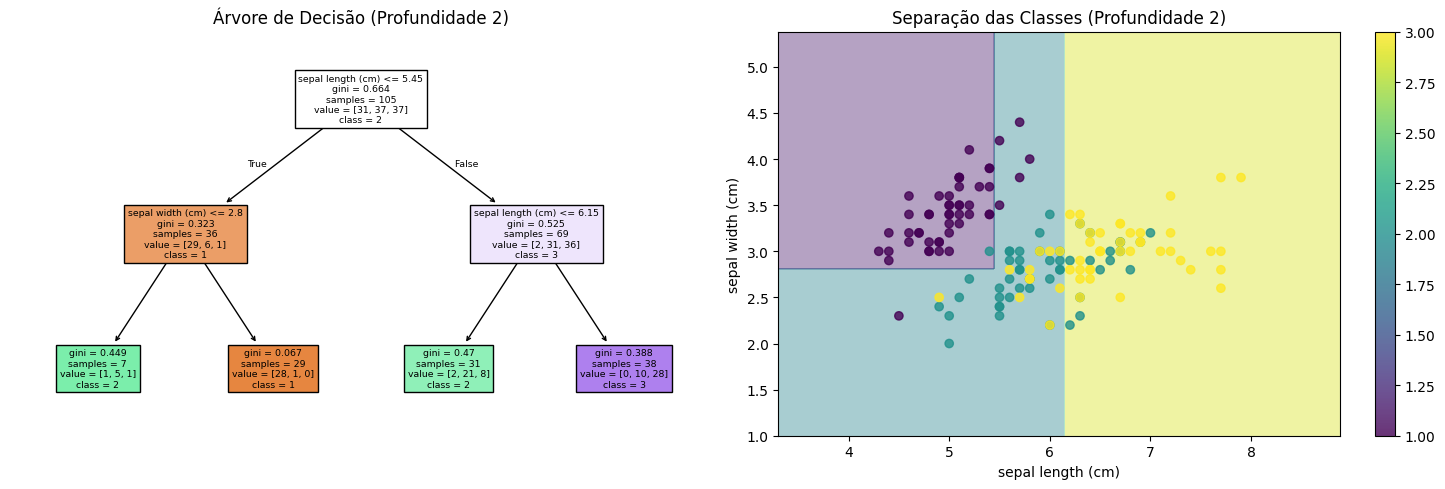


Profundidade 3:
Acurácia: 0.7556
Figura salva em: arvore_profundidade_3.png


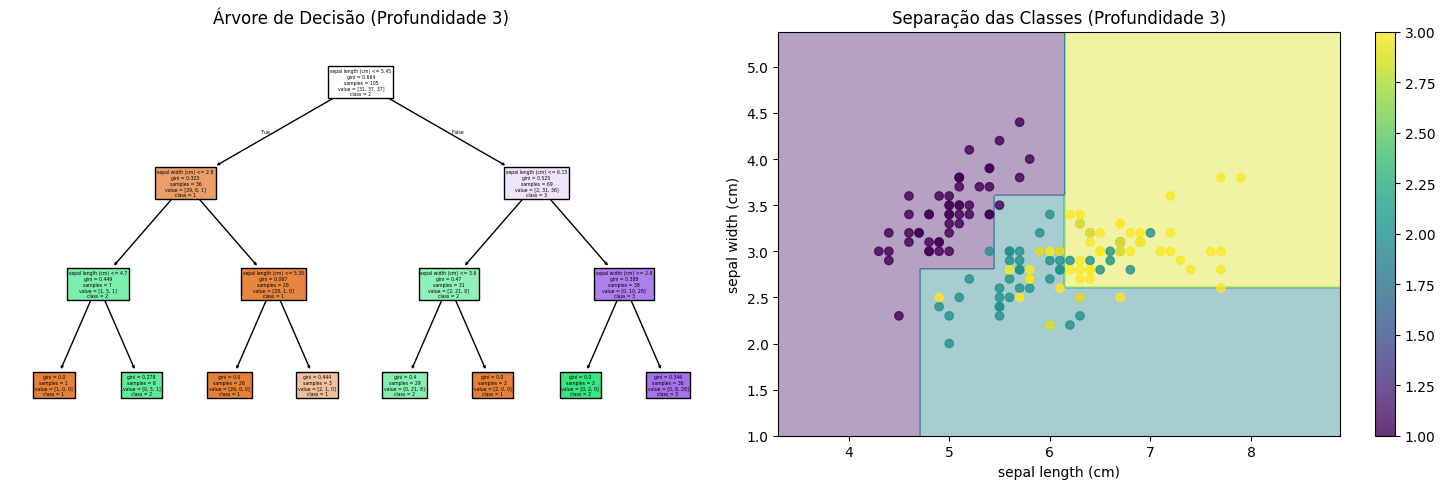


Profundidade 4:
Acurácia: 0.7556
Figura salva em: arvore_profundidade_4.png


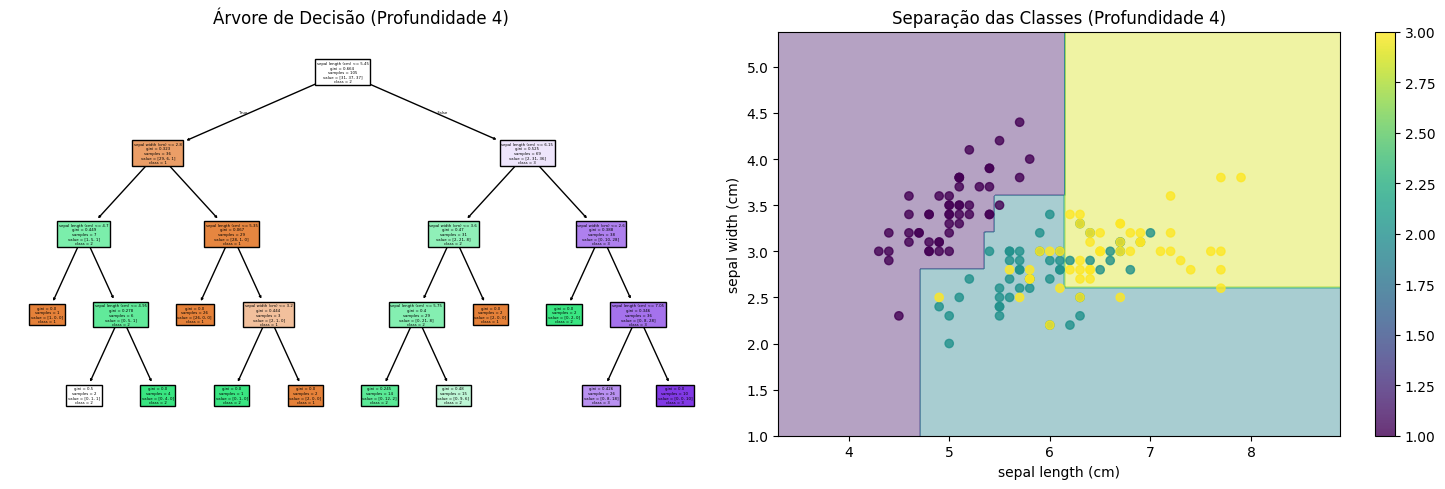

In [ ]:
#@title Alterar para usar 1,2 no lugar do 0,1 da Iris e salvar PNGs
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Carregar o dataset Iris
iris = load_iris()
X = iris.data[:, [0, 1]]  # Apenas as duas primeiras características para visualização
y = iris.target + 1       # Alterar classes para 1, 2, 3

# Dividir os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Função para treinar o modelo, mostrar e salvar resultados
def train_and_visualize(depth):
    # Criar e treinar o modelo
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)

    # Calcular acurácia
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\nProfundidade {depth}:")
    print(f"Acurácia: {accuracy:.4f}")

    # Criar figura com dois subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot da árvore
    plot_tree(clf, feature_names=iris.feature_names[:2],
              class_names=[str(c) for c in np.unique(y)], filled=True, ax=ax1)
    ax1.set_title(f'Árvore de Decisão (Profundidade {depth})')

    # Plot da separação das classes
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax2.contourf(xx, yy, Z, alpha=0.4)
    scatter = ax2.scatter(X[:, 0], X[:, 1], c=y, alpha=0.8)
    ax2.set_xlabel(iris.feature_names[0])
    ax2.set_ylabel(iris.feature_names[1])
    ax2.set_title(f'Separação das Classes (Profundidade {depth})')
    plt.colorbar(scatter, ax=ax2)

    plt.tight_layout()

    # Salvar em PNG
    filename = f"arvore_profundidade_{depth}.png"
    plt.savefig(filename, dpi=150)
    print(f"Figura salva em: {filename}")

    plt.show()

# Testar diferentes profundidades
for depth in [2, 3, 4]:
    train_and_visualize(depth)


#### Só a petala ou a sepala


Profundidade 2:
Acurácia: 0.7556
Figura salva em: arvore_sepala_profundidade_2.png


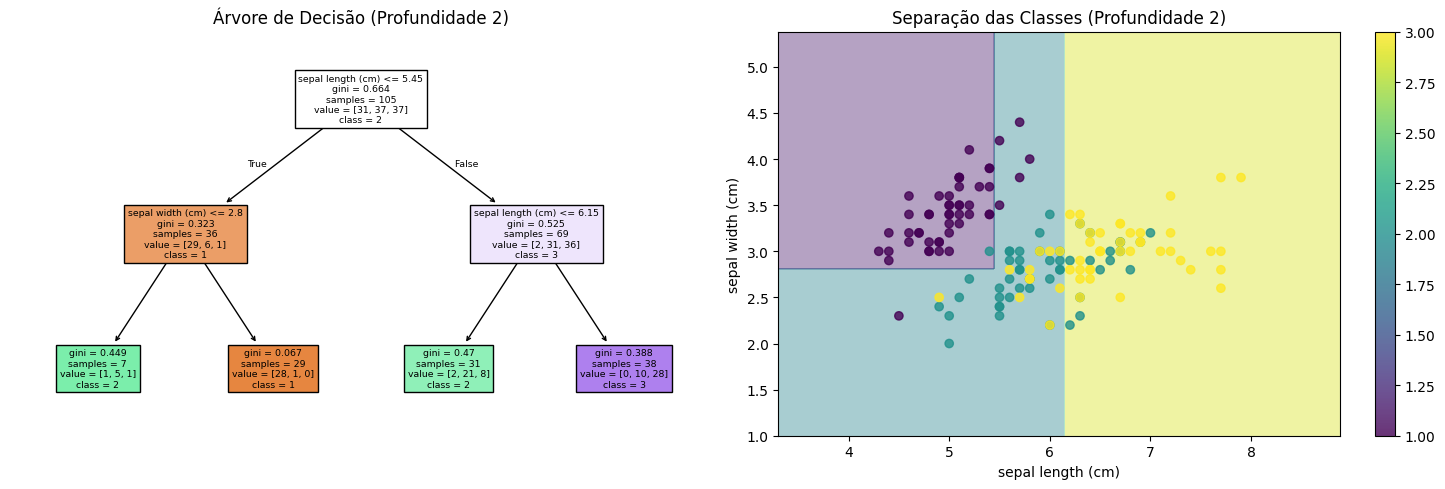


Profundidade 3:
Acurácia: 0.7556
Figura salva em: arvore_sepala_profundidade_3.png


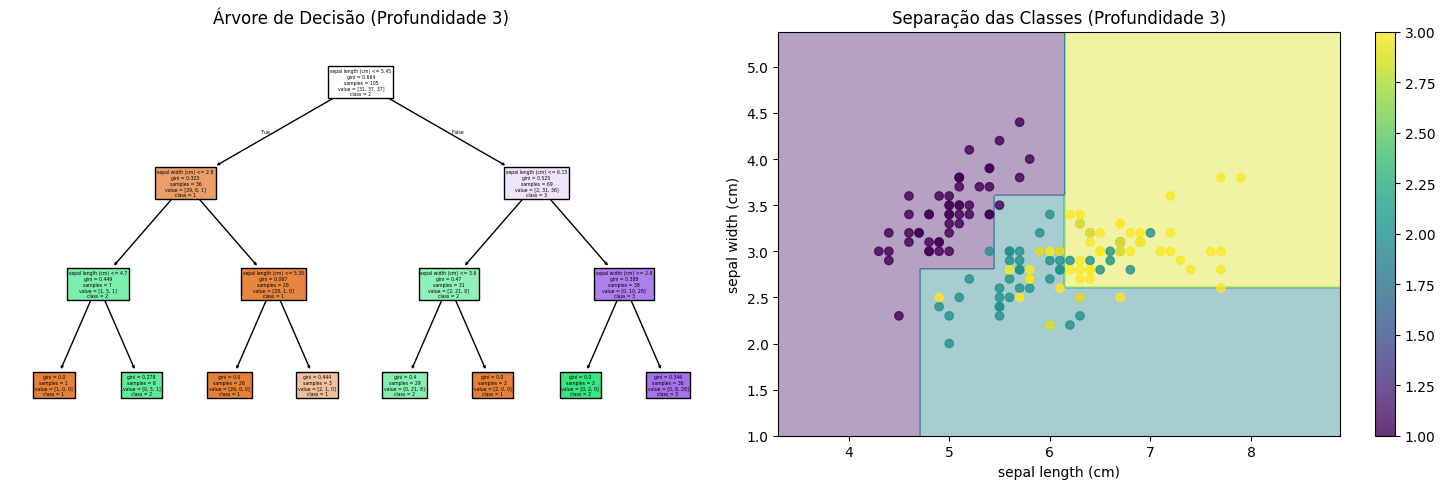


Profundidade 4:
Acurácia: 0.7556
Figura salva em: arvore_sepala_profundidade_4.png


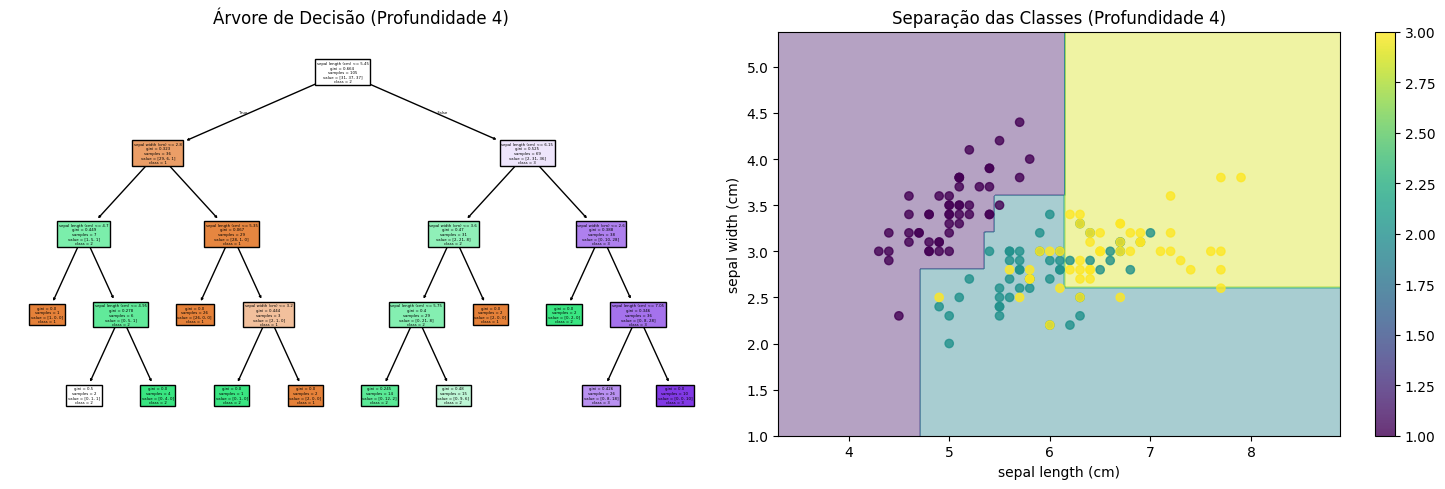

In [ ]:
#@title Iris Usando Somente a Sépala (salvando PNGs), experimente e compare com a solução usando somente a petala (2,3)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Carregar o dataset Iris
iris = load_iris()
X = iris.data[:, [0, 1]]  # Usando comprimento e largura da sépala
y = iris.target + 1       # Classes de 1 a 3

# Dividir os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Função para treinar o modelo, mostrar e salvar resultados
def train_and_visualize(depth):
    # Criar e treinar o modelo
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)

    # Calcular acurácia
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\nProfundidade {depth}:")
    print(f"Acurácia: {accuracy:.4f}")

    # Criar figura com dois subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot da árvore
    plot_tree(clf, feature_names=[iris.feature_names[0], iris.feature_names[1]],
              class_names=[str(c) for c in np.unique(y)], filled=True, ax=ax1)
    ax1.set_title(f'Árvore de Decisão (Profundidade {depth})')

    # Plot da separação das classes
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax2.contourf(xx, yy, Z, alpha=0.4)
    scatter = ax2.scatter(X[:, 0], X[:, 1], c=y, alpha=0.8)
    ax2.set_xlabel(iris.feature_names[0])
    ax2.set_ylabel(iris.feature_names[1])
    ax2.set_title(f'Separação das Classes (Profundidade {depth})')
    plt.colorbar(scatter, ax=ax2)

    plt.tight_layout()

    # Salvar em PNG
    filename = f"arvore_sepala_profundidade_{depth}.png"
    plt.savefig(filename, dpi=150)
    print(f"Figura salva em: {filename}")

    plt.show()

# Testar diferentes profundidades
for depth in [2, 3, 4]:
    train_and_visualize(depth)


## Agora iremos ler vários Datasets **Atenção se estiver no Harp ou no Colab**

* No Colab usaremos o wget e colocar nas variáveis df1,df2....
  1. Predição de Cultura
  2. Arroz
  3. Feijão
  4. Adult

In [ ]:
#colab
import pandas as pd
!wget -q https://raw.githubusercontent.com/AdilsonRLopes/datasets/main/predicao_cultura.csv
df1 = pd.read_csv("predicao_cultura.csv")
!wget -q "https://raw.githubusercontent.com/Knovsa11/Rice-Type-Classification/refs/heads/main/riceClassification.csv"
df2 = pd.read_csv("riceClassification.csv")
!wget -q "https://raw.githubusercontent.com/arduinoufv/inf121/refs/heads/main/datasets/drybean.csv"
df3 = pd.read_csv("drybean.csv")
!wget -q "https://raw.githubusercontent.com/saravrajavelu/Adult-Income-Analysis/master/adult.csv"
df4 = pd.read_csv("adult.csv")

In [ ]:
#harp
import pandas as pd
df1 = pd.read_csv("/home/inf121/pratica/predicao_cultura.csv")
df2 = pd.read_csv("/home/inf121/pratica/riceClassification.csv")
df3 = pd.read_csv("/home/inf121/pratica/drybean.csv")
df4 = pd.read_csv("/home/inf121/pratica/adult.csv")


## **TAREFA 3**

* Alterar o código abaixo para fazer cada um dos datasets, ver numero de atributos numericos e categoricos, numero de classes e amostras, acurácia e tempo de execução para arvore decisão com profundidade 8.

Dataset | Numericos | Categoricos | Amostras | Acurácia | Tempo de Execução
--|--|--|--|--|--
Cultura |
Arroz |
Feijao |
Adult |



In [ ]:
# Aqui voce ira escolher um por um, executar, voltar aqui, executar para próxim
target = "income" # Cultura é "target", arroz e feijao  é "Class", adult é "income"
df = df4 # usar df1,df2,df3 ou df4

In [ ]:
#@title Execute para ver as característica do Dataset - Análise + Árvore de Decisão
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

def analisar_dataframe(df, target):
    # Separar tipos de atributos
    atributos_numericos = df.drop(columns=[target]).select_dtypes(include=[np.number]).columns
    atributos_categoricos = df.drop(columns=[target]).select_dtypes(exclude=[np.number]).columns

    print("Número de amostras:", len(df))
    print("Número de atributos numéricos:", len(atributos_numericos))
    print("Número de atributos categóricos:", len(atributos_categoricos))
    print("Número de classes na variável alvo:", df[target].nunique())

    # One-hot encoding para atributos categóricos
    df_encoded = pd.get_dummies(df, drop_first=True)

    # Divisão treino/teste
    X = df_encoded.drop(columns=[col for col in df_encoded.columns if target in col])
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Treinamento + tempo
    inicio = time.time()
    clf = DecisionTreeClassifier(max_depth=8, random_state=42)
    clf.fit(X_train, y_train)
    fim = time.time()

    # Acurácia
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"Acurácia: {acc:.4f}")
    print(f"Tempo de execução: {fim - inicio:.4f} segundos")

    return clf

# Exemplo de uso:
clf = analisar_dataframe(df, target)


Número de amostras: 48842
Número de atributos numéricos: 6
Número de atributos categóricos: 8
Número de classes na variável alvo: 2
Acurácia: 0.8635
Tempo de execução: 0.2776 segundos


## **TAREFA 4**

* Agora iremos estudar as árvores do Feijão e do Adult
* Usaremos uma profundidade pequena = 3
* Achar três folhas: a folha com menor entropia, a folha com maior quantidade de uma classe e a folha com maior entropia

dataset | Menor Entropia | Maior Qte | Maior Entropia
--|--|--|--
feijao |
adult |

* Quais as perguntas que levaram a "Maior Qte" ?


* Agora para gini

dataset | Acurácia |Menor Gini | Maior Qte | Maior Gini
--|--|--|--|--
feijao |
adult |

* Quais as perguntas que levaram ao "Menor Gini" ?


Acurácia: 0.8506
Tempo de execução: 0.0895 segundos
Árvore salva em: arvore_decisao_gini.png


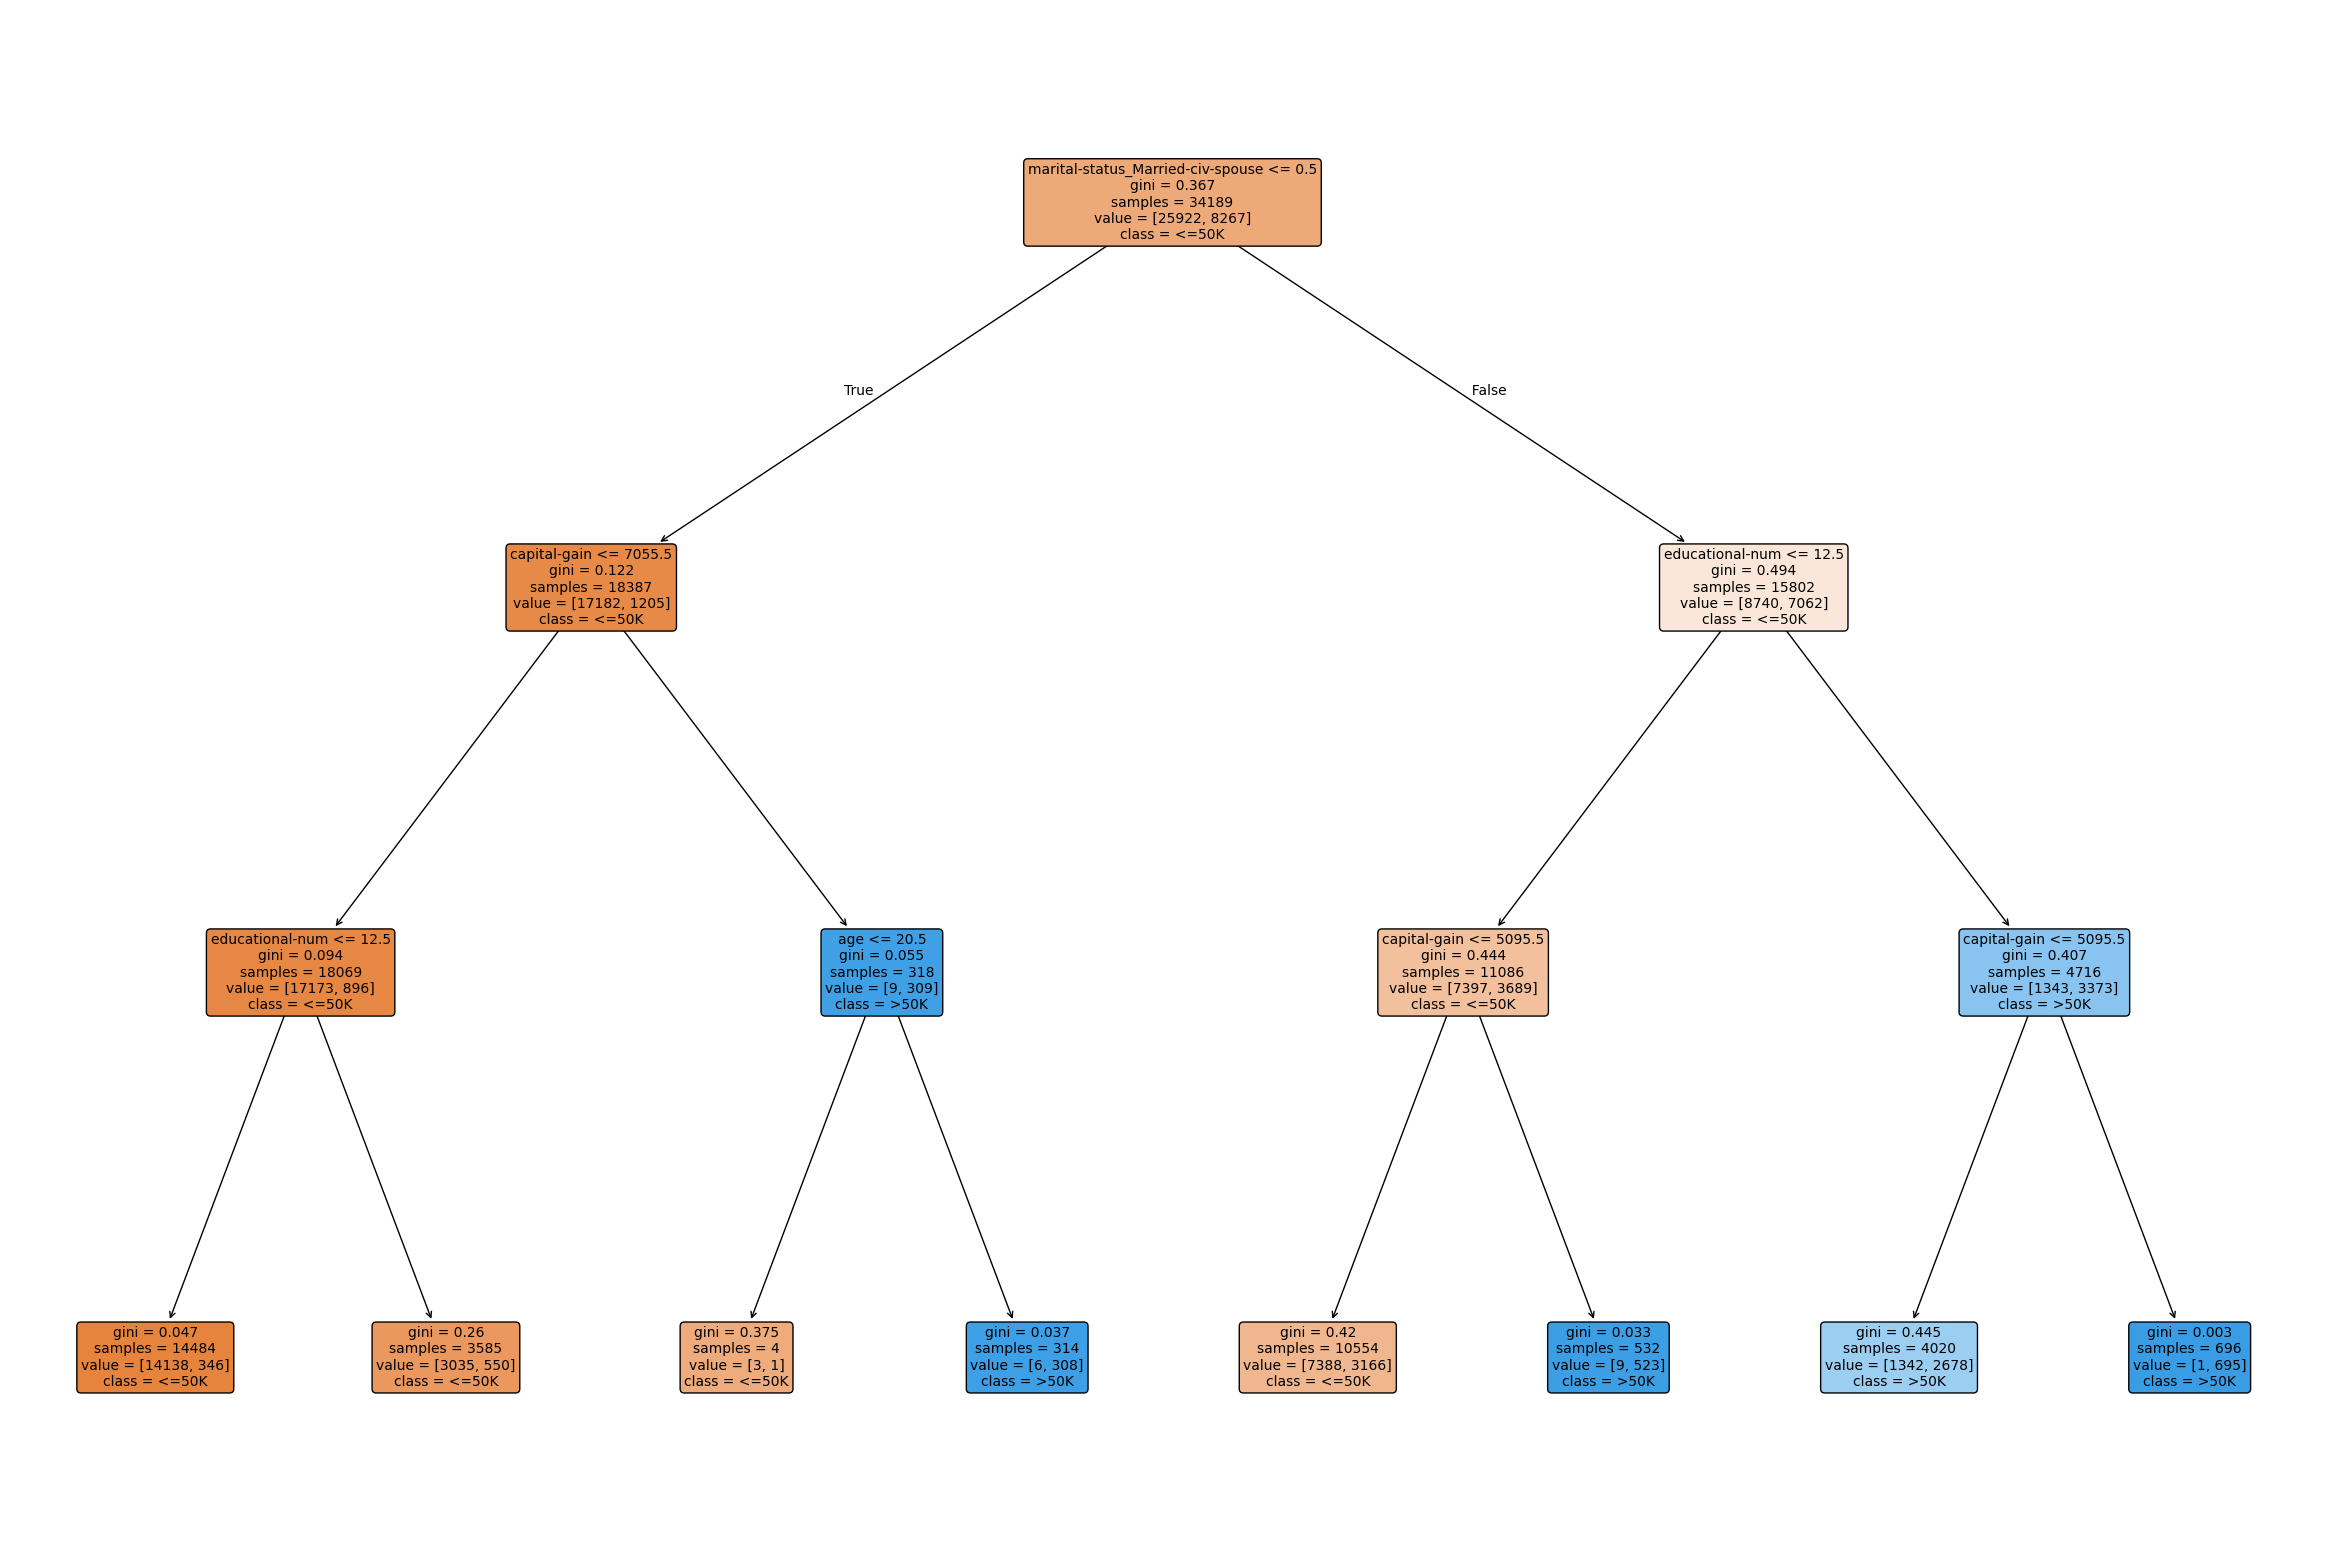

In [ ]:
#@title Árvore de Decisão (profundidade 3, visualização + salvar PNG)
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

def arvore_decisao(df, target, criterio="gini"):
    # Separar tipos de atributos
    atributos_numericos = df.drop(columns=[target]).select_dtypes(include=[np.number]).columns
    atributos_categoricos = df.drop(columns=[target]).select_dtypes(exclude=[np.number]).columns

    # One-hot encoding para atributos categóricos
    df_encoded = pd.get_dummies(df, drop_first=True)

    # Divisão treino/teste
    X = df_encoded.drop(columns=[col for col in df_encoded.columns if target in col])
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Treinamento + tempo
    inicio = time.time()
    clf = DecisionTreeClassifier(max_depth=3, criterion=criterio, random_state=42)
    clf.fit(X_train, y_train)
    fim = time.time()

    # Acurácia
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"Acurácia: {acc:.4f}")
    print(f"Tempo de execução: {fim - inicio:.4f} segundos")

    # Mostrar e salvar a árvore
    plt.figure(figsize=(30, 20))
    plot_tree(clf, feature_names=X.columns, class_names=[str(c) for c in np.unique(y)],
              filled=True, rounded=True, fontsize=10)

    filename = f"arvore_decisao_{criterio}.png"
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    print(f"Árvore salva em: {filename}")

    plt.show()

    return clf

# Exemplo de uso:
clf = arvore_decisao(df, target, criterio="gini")  # ou "entropy"


In [ ]:
# APENAS para Colab
# Instalação do supertree
!pip install supertree==0.5.5 >& /dev/null # ou simplesmente pip install supertree

In [ ]:
target = "Class" # Cultura é "target", arroz e feijao  é "Class", adult é "income_50K"
df = df3 # usar df1,df2,df3 ou df4

## Agora veja com o supertree

In [ ]:
# Usar supertree para visualização interativa (sem class_names)
from supertree import SuperTree
from sklearn.preprocessing import LabelEncoder

def arvore_com_supertree(df, target, criterio="gini"):
    # Separar variáveis numéricas e categóricas
    num = df.drop(columns=[target]).select_dtypes(include=[np.number]).columns
    cat = df.drop(columns=[target]).select_dtypes(exclude=[np.number]).columns

    print("Número de amostras:", len(df))
    print("Número de atributos numéricos:", len(num))
    print("Número de atributos categóricos:", len(cat))
    print("Número de classes na variável alvo:", df[target].nunique())


# Separar as variáveis independentes (X) e dependente (y)
    X = df.drop(columns=[target])
    y = df[target]


    # Codificar as variáveis categóricas
    for col in X.select_dtypes(include="object").columns:
      X[col] = LabelEncoder().fit_transform(X[col])

    # Codificar a variável alvo
    y = LabelEncoder().fit_transform(y)

    # Separar treino e teste
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Treinamento e medição de tempo
    import time
    from sklearn.tree import DecisionTreeClassifier
    inicio = time.time()
    clf = DecisionTreeClassifier(max_depth=3, criterion=criterio, random_state=42)
    clf.fit(X_train, y_train)
    fim = time.time()

    acc = clf.score(X_test, y_test)
    print(f"Acurácia: {acc:.4f}")
    print(f"Tempo de execução: {fim - inicio:.4f} segundos")

    # Criar a visualização com SuperTree
    super_tree = SuperTree(
        clf,
        X_train,
        y_train,
        feature_names=X_train.columns.tolist()
    )
    super_tree.show_tree()

    return clf

# Exemplo de uso:
clf = arvore_com_supertree(df, target, criterio="entropy")


Número de amostras: 13611
Número de atributos numéricos: 16
Número de atributos categóricos: 0
Número de classes na variável alvo: 7
Acurácia: 0.7980
Tempo de execução: 0.1568 segundos


# Digits

[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]
Que numero é este ?


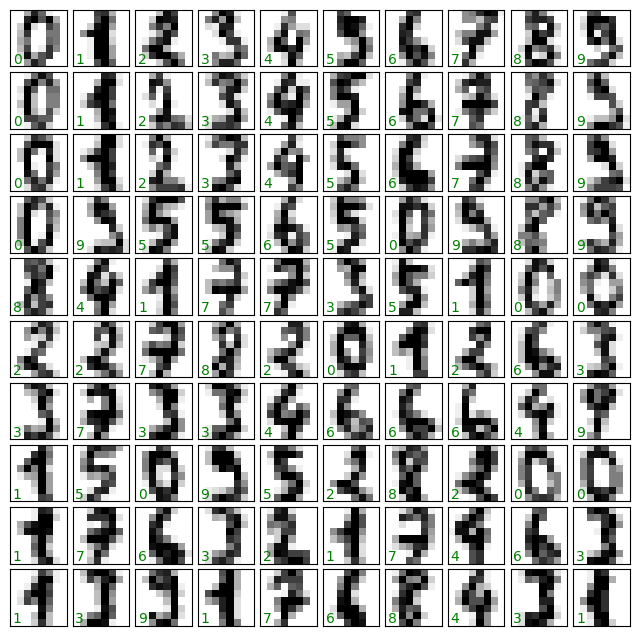

In [ ]:
#@title Visualizando
from sklearn.datasets import load_digits
digits = load_digits()
digits.images.shape
import matplotlib.pyplot as plt


print(digits.images[0])
print("Que numero é este ?")

fig, axes = plt.subplots(10, 10, figsize=(8, 8),
                         subplot_kw={'xticks':[], 'yticks':[]},
                         gridspec_kw=dict(hspace=0.1, wspace=0.1))

for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='binary', interpolation='nearest')
    ax.text(0.05, 0.05, str(digits.target[i]),
            transform=ax.transAxes, color='green')

In [ ]:
#@title Quiz com Digits (valores da matriz)
from sklearn.datasets import load_digits
import random
import ipywidgets as widgets
from IPython.display import display, clear_output

# Carregar dataset digits
digits = load_digits()

# Função para mostrar uma questão
def nova_questao():
    clear_output(wait=True)
    idx = random.randint(0, len(digits.images)-1)
    matriz = digits.images[idx]
    label_correto = digits.target[idx]

    # Mostrar a matriz numérica
    print("Matriz de pixels (valores entre 0 e 16):")
    print(matriz.astype(int))
    print("\nQue número é este?")

    # Criar botões 0-9
    def resposta_clicada(b):
        if int(b.description) == label_correto:
            print(f"✅ Correto! Era o número {label_correto}")
        else:
            print(f"❌ Errado. Era o número {label_correto}")
        # Botão de próxima questão
        proximo = widgets.Button(description="Próxima")
        display(proximo)
        proximo.on_click(lambda x: nova_questao())

    botoes = [widgets.Button(description=str(i)) for i in range(10)]
    display(widgets.HBox(botoes))
    for b in botoes:
        b.on_click(resposta_clicada)

# Iniciar quiz
nova_questao()


Matriz de pixels (valores entre 0 e 16):
[[ 0  0  1 14 13  4  0  0]
 [ 0  3 15 12 11 15  0  0]
 [ 0  8 11  1  7 13  0  0]
 [ 0  1 13 14 16  1  0  0]
 [ 0  0  0 14 13 14  2  0]
 [ 0  0  2 12  0  9  8  0]
 [ 0  0  3 13  4 12  6  0]
 [ 0  0  0  9 14 13  1  0]]

Que número é este?


❌ Errado. Era o número 8


Button(description='Próxima', style=ButtonStyle())

## **TAREFA 5**

* Qual o dígito que tem mais erro com a profundidade X, onde X pode ser 3,5,8 ou 10,  na matriz de confusão ?

Profundidade | Digito | erro
--|--|--
3|
5|
8|
10|


Depth: 3, Criterion: gini, Min Samples Split: 5, Accuracy: 0.4759


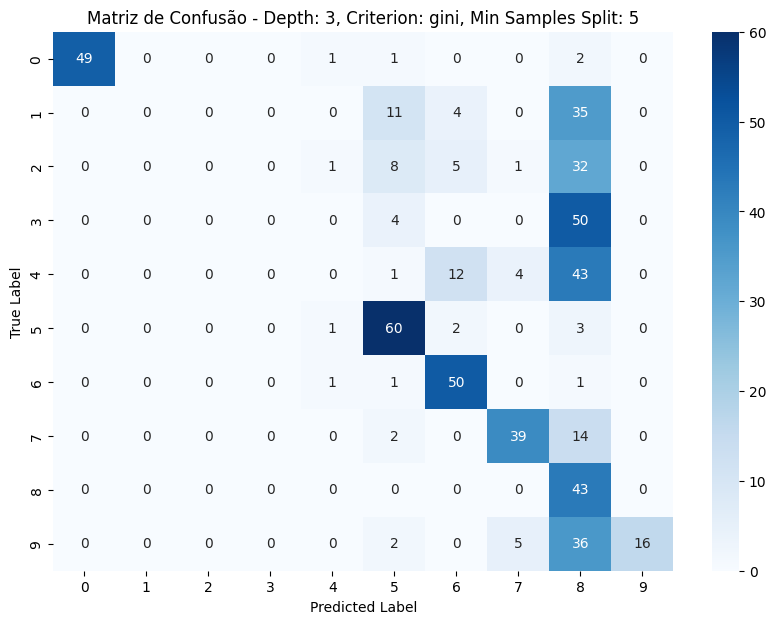

Depth: 5, Criterion: gini, Min Samples Split: 5, Accuracy: 0.6537


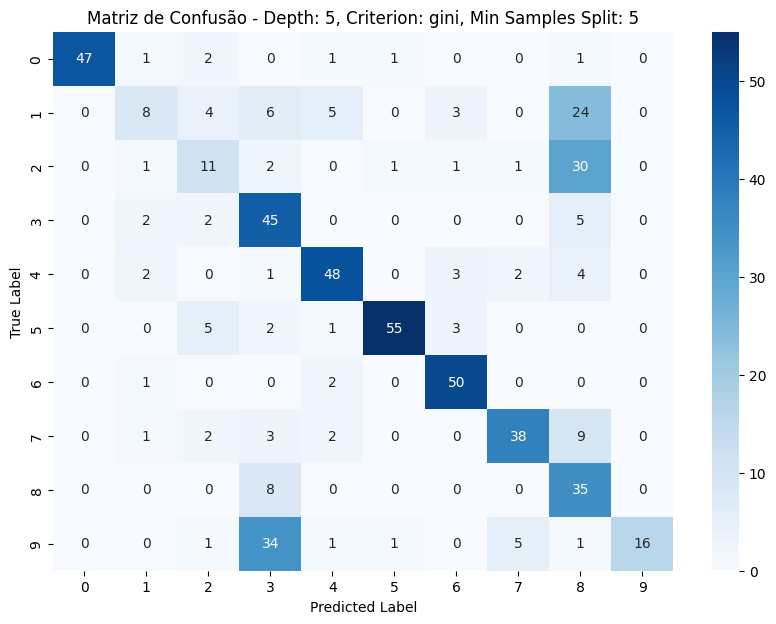

Depth: 8, Criterion: gini, Min Samples Split: 5, Accuracy: 0.8241


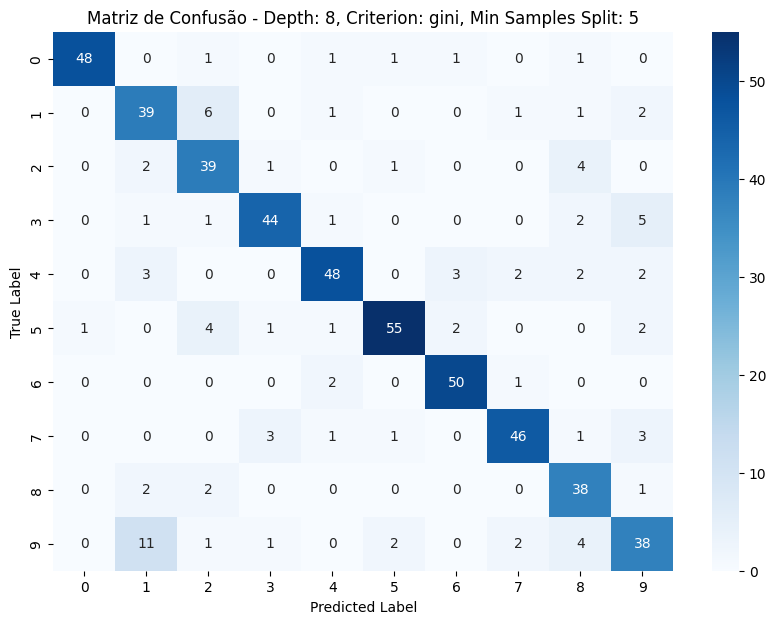

Depth: 10, Criterion: gini, Min Samples Split: 5, Accuracy: 0.8481


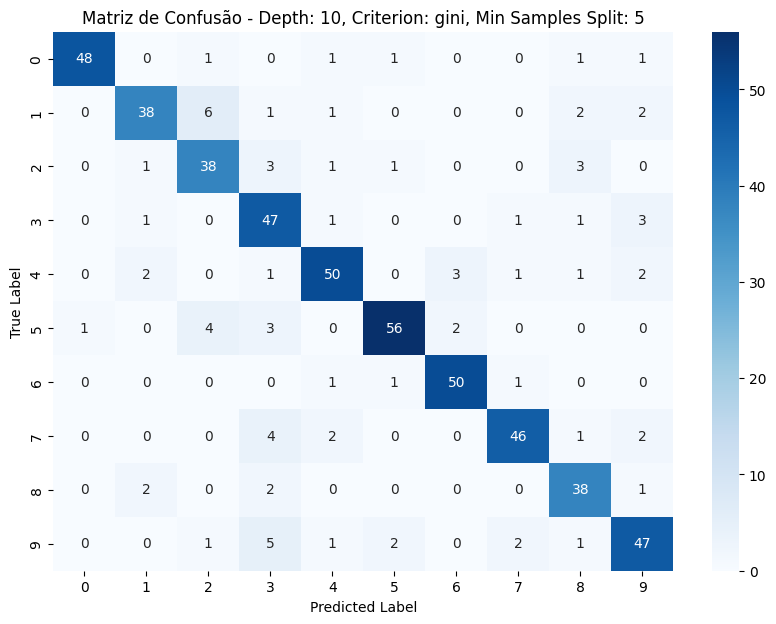

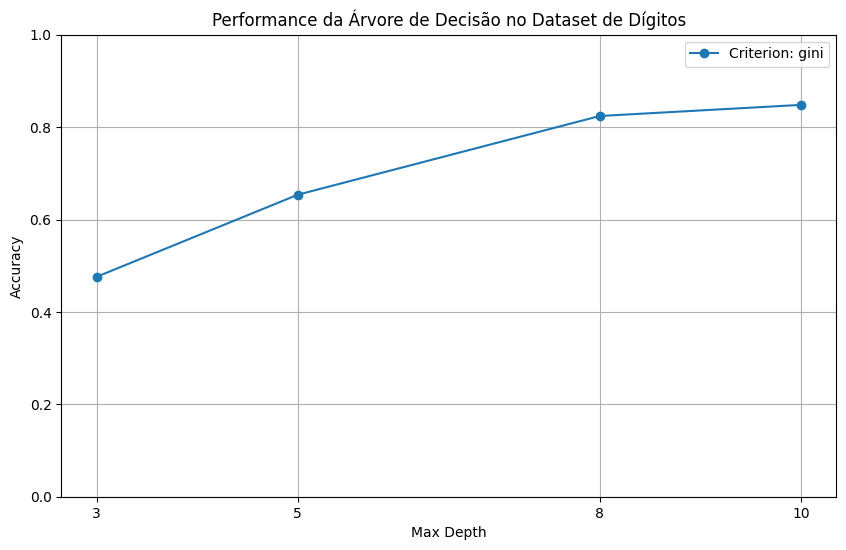

In [ ]:
#@title Arvore Decisão para Digits, execute para completar a tabela da Tarefa 5

import numpy as np
import pandas as pd
from sklearn.datasets import load_digits  # Usando o dataset de dígitos
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar o dataset de dígitos
data = load_digits()
X = data.data
y = data.target

# Dividir o conjunto de dados em treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Parâmetros da árvore de decisão
max_depths = [3, 5, 8, 10]
criteria = ['gini']
min_samples_split = [5]  # Exemplo de valores para o número mínimo de amostras para fazer um split

# Armazenar resultados
results = []

# Loop através dos parâmetros
for max_depth in max_depths:
    for criterion in criteria:
        for min_samples in min_samples_split:
            # Criar o classificador de árvore de decisão
            model = DecisionTreeClassifier(max_depth=max_depth,
                                            criterion=criterion,
                                            min_samples_split=min_samples,
                                            random_state=42)
            model.fit(X_train, y_train)  # Treinar o modelo
            y_pred = model.predict(X_test)  # Fazer previsões

            # Calcular a acurácia e armazenar os resultados
            accuracy = accuracy_score(y_test, y_pred)
            results.append((max_depth, criterion, min_samples, accuracy))
            print(f'Depth: {max_depth}, Criterion: {criterion}, Min Samples Split: {min_samples}, Accuracy: {accuracy:.4f}')

            # Calcular e exibir a matriz de confusão
            cm = confusion_matrix(y_test, y_pred)
            plt.figure(figsize=(10, 7))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.arange(10), yticklabels=np.arange(10))
            plt.title(f'Matriz de Confusão - Depth: {max_depth}, Criterion: {criterion}, Min Samples Split: {min_samples}')
            plt.xlabel('Predicted Label')
            plt.ylabel('True Label')
            plt.show()

# Converter resultados em DataFrame para visualização
results_df = pd.DataFrame(results, columns=['Max Depth', 'Criterion', 'Min Samples Split', 'Accuracy'])

# Gráfico de comparação
plt.figure(figsize=(10, 6))
for criterion in criteria:
    subset = results_df[results_df['Criterion'] == criterion]
    plt.plot(subset['Max Depth'], subset['Accuracy'], marker='o', label=f'Criterion: {criterion}')
plt.title('Performance da Árvore de Decisão no Dataset de Dígitos')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.xticks(max_depths)
plt.ylim(0, 1)
plt.legend()
plt.grid()
plt.show()


# Jogo

Ideia: voce pode escolher uma folha e ir abrindo montando sua árvore. Escolhe a folha, o limiar, o feature, seleciona para DIVIDIR...depois escolhe mais uma folha e assim por diante....


In [2]:
#@title Jogo Interativo de Construção de Árvore de Decisão (versão corrigida)
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import ipywidgets as widgets
from IPython.display import display, clear_output
from graphviz import Digraph

# ============
# Dataset Adult (apenas numéricos)
# ============
adult = fetch_openml(name="adult", version=2, as_frame=True)
df = adult.frame.copy()
target = "class"
y = (df[target] == ">50K").astype(int)
X = df.select_dtypes(include=[np.number])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ============
# Estrutura da Árvore feita pelo usuário
# ============
node_counter = 0

def make_leaf(mask):
    global node_counter
    node_id = node_counter
    node_counter += 1
    return {
        "id": node_id,
        "mask": mask,
        "is_leaf": True,
        "feature": None,
        "threshold": None,
        "children": []
    }

root = make_leaf(np.ones(len(X_train), dtype=bool))  # folha raiz
leaves = [root]  # começa com apenas a raiz

# ============
# Funções de apoio
# ============
def gini_impurity(y_subset):
    if len(y_subset) == 0:
        return 0
    p = np.mean(y_subset)
    return 2 * p * (1 - p)

def describe_leaf(node):
    y_sub = y_train[node["mask"]]
    n = len(y_sub)
    if n == 0:
        return f"Folha {node['id']} (vazia)"
    gini = gini_impurity(y_sub)
    counts = np.bincount(y_sub, minlength=2)
    return f"Folha {node['id']}: n={n}, 0={counts[0]}, 1={counts[1]}, gini={gini:.3f}"

def predict_tree(X_data, node):
    if node["is_leaf"]:
        y_sub = y_train[node["mask"]]
        if len(y_sub) == 0:
            return np.zeros(len(X_data), dtype=int)
        maj = int(np.mean(y_sub) >= 0.5)
        return np.full(len(X_data), maj)
    else:
        feature = node["feature"]
        thr = node["threshold"]
        left, right = node["children"]
        mask_left = X_data[feature] <= thr
        y_pred = np.zeros(len(X_data), dtype=int)
        y_pred[mask_left] = predict_tree(X_data[mask_left], left)
        y_pred[~mask_left] = predict_tree(X_data[~mask_left], right)
        return y_pred

def compute_accuracy():
    y_pred = predict_tree(X_test, root)
    return accuracy_score(y_test, y_pred)

def build_graph(node, dot=None):
    if dot is None:
        dot = Digraph()
    if node["is_leaf"]:
        y_sub = y_train[node["mask"]]
        counts = np.bincount(y_sub, minlength=2)
        label = f"Leaf {node['id']}\\n0={counts[0]}, 1={counts[1]}"
        dot.node(str(node["id"]), label, shape="box")
    else:
        label = f"{node['feature']} <= {node['threshold']:.2f}"
        dot.node(str(node["id"]), label, shape="ellipse")
        for child in node["children"]:
            build_graph(child, dot)
            dot.edge(str(node["id"]), str(child["id"]))
    return dot

# ============
# Interface
# ============
leaf_dropdown = widgets.Dropdown(description="Folha:", options=[])
feature_dropdown = widgets.Dropdown(description="Feature:", options=list(X.columns))
threshold_slider = widgets.FloatSlider(description="Limiar", step=1.0)
select_button = widgets.Button(description="Selecionar divisão", button_style="success")
evaluate_button = widgets.Button(description="Avaliar", button_style="info")
output = widgets.Output()

def update_leaf_dropdown():
    leaf_dropdown.options = [(describe_leaf(l), l["id"]) for l in leaves]

def on_leaf_change(change):
    if not change["new"]:
        return
    node_id = change["new"]
    node = next(l for l in leaves if l["id"] == node_id)
    feat = feature_dropdown.value
    vals = X_train.loc[node["mask"], feat]
    if len(vals) == 0:
        threshold_slider.min = 0
        threshold_slider.max = 1
        threshold_slider.step = 0.1
        threshold_slider.value = 0.5
    else:
        threshold_slider.min = float(vals.min())
        threshold_slider.max = float(vals.max())
        threshold_slider.step = (threshold_slider.max - threshold_slider.min) / 50
        threshold_slider.value = float(vals.median())

def on_feature_change(change):
    on_leaf_change({"new": leaf_dropdown.value})

def on_select_click(b):
    node_id = leaf_dropdown.value
    node = next(l for l in leaves if l["id"] == node_id)
    feat = feature_dropdown.value
    thr = threshold_slider.value

    # dividir folha
    mask = node["mask"]
    left_mask = mask & (X_train[feat] <= thr)
    right_mask = mask & (X_train[feat] > thr)
    left = make_leaf(left_mask)
    right = make_leaf(right_mask)

    node["is_leaf"] = False
    node["feature"] = feat
    node["threshold"] = thr
    node["children"] = [left, right]

    # atualizar lista de folhas
    leaves.remove(node)
    leaves.extend([left, right])

    # atualizar interface
    update_leaf_dropdown()
    with output:
        clear_output()
        print("✅ Divisão realizada!")
        for l in leaves:
            print(describe_leaf(l))
        print(f"Acurácia no teste: {compute_accuracy():.3f}")
        display(build_graph(root))

def on_evaluate_click(b):
    node_id = leaf_dropdown.value
    node = next(l for l in leaves if l["id"] == node_id)
    feat = feature_dropdown.value
    thr = threshold_slider.value
    y_sub = y_train[node["mask"]]

    gini_before = gini_impurity(y_sub)
    left = y_train[node["mask"] & (X_train[feat] <= thr)]
    right = y_train[node["mask"] & (X_train[feat] > thr)]
    if len(y_sub) > 0:
        gini_after = (len(left)/len(y_sub))*gini_impurity(left) + (len(right)/len(y_sub))*gini_impurity(right)
    else:
        gini_after = 0

    with output:
        clear_output()
        print(describe_leaf(node))
        print(f"Gini antes: {gini_before:.3f}, Gini após: {gini_after:.3f}")
        print(f"Acurácia atual (sem expandir): {compute_accuracy():.3f}")
        display(build_graph(root))

leaf_dropdown.observe(on_leaf_change, names="value")
feature_dropdown.observe(on_feature_change, names="value")
select_button.on_click(on_select_click)
evaluate_button.on_click(on_evaluate_click)

# Inicializa interface
update_leaf_dropdown()
on_leaf_change({"new": leaf_dropdown.value})  # inicializa slider
display(leaf_dropdown, feature_dropdown, threshold_slider, widgets.HBox([evaluate_button, select_button]), output)


Dropdown(description='Folha:', options=(('Folha 0: n=34189, 0=25922, 1=8267, gini=0.367', 0),), value=0)

Dropdown(description='Feature:', options=('age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'h…

FloatSlider(value=0.0, description='Limiar', step=1.0)

Output()

# Outro Jogo

Aqui voce terá que calcular os gini da raiz, esquerda e direita e escrever as equações

Por exemplo:

```
raiz = 1 - (3/4)**2 - (1/4)**2
```

Voce pode escolher A,B ou C como feature, e depois um limiar.
Em seguida, selecionar o **MOSTRAR**, fazer as "contas" e depois conferir.


In [ ]:
#@title Jogo do Gini com 3 caixas e sorteio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import ipywidgets as widgets
from IPython.display import display, clear_output

colors = {0:"red", 1:"blue", 2:"green"}

# ============
# Função para criar dataset novo
# ============
def criar_dataset():
    X, y = make_classification(
        n_samples=24, n_features=3, n_informative=3,
        n_redundant=0, n_classes=3, n_clusters_per_class=1,
        random_state=np.random.randint(0,10000)
    )
    df = pd.DataFrame(X, columns=["A", "B", "C"])
    df["class"] = y
    X_train, X_test, y_train, y_test = train_test_split(
        df.drop("class", axis=1), df["class"], test_size=0.3, random_state=42
    )
    test = X_train.copy()
    test["class"] = y_train
    return test

test = criar_dataset()

# ============
# Widgets
# ============
feature_dropdown = widgets.Dropdown(description="Coluna:", options=["A","B","C"])
threshold_slider = widgets.FloatSlider(description="Limiar", step=0.1)
show_button = widgets.Button(description="MOSTRAR", button_style="info")
formula_root = widgets.Text(description="Raiz =", placeholder="1 - (...)")
formula_left = widgets.Text(description="Esquerda =", placeholder="1 - (...)")
formula_right = widgets.Text(description="Direita =", placeholder="1 - (...)")
check_button = widgets.Button(description="AVALIAR", button_style="success")
new_button = widgets.Button(description="NOVO EXEMPLO", button_style="warning")
output = widgets.Output()

gini_real = {}

def gini_impurity(y_subset):
    if len(y_subset) == 0:
        return 0
    probs = [np.mean(y_subset==c) for c in np.unique(y_subset)]
    return 1 - sum(p**2 for p in probs)

def atualizar_slider():
    feat = feature_dropdown.value
    vals = test[feat]
    threshold_slider.min = float(vals.min())
    threshold_slider.max = float(vals.max())
    threshold_slider.value = float(vals.median())
    threshold_slider.step = (threshold_slider.max - threshold_slider.min)/50

feature_dropdown.observe(lambda change: atualizar_slider(), names="value")

def on_show_click(b):
    global gini_real
    feat = feature_dropdown.value
    thr = threshold_slider.value

    y_all = test["class"]
    mask = test[feat] <= thr
    y_left = test.loc[mask, "class"]
    y_right = test.loc[~mask, "class"]

    gini_real = {
        "root": gini_impurity(y_all),
        "left": gini_impurity(y_left),
        "right": gini_impurity(y_right),
    }

    with output:
        clear_output()
        fig, ax = plt.subplots(1,3, figsize=(12,4))
        # raiz
        ax[0].set_title("Raiz")
        for i, yi in enumerate(y_all):
            ax[0].scatter(i, 0, c=colors[yi], s=200)
        ax[0].set_xticks([]); ax[0].set_yticks([])

        # esquerda
        ax[1].set_title(f"{feat} <= {thr:.2f}")
        for i, yi in enumerate(y_left):
            ax[1].scatter(i, 0, c=colors[yi], s=200)
        ax[1].set_xticks([]); ax[1].set_yticks([])

        # direita
        ax[2].set_title(f"{feat} > {thr:.2f}")
        for i, yi in enumerate(y_right):
            ax[2].scatter(i, 0, c=colors[yi], s=200)
        ax[2].set_xticks([]); ax[2].set_yticks([])

        plt.show()
        print("Conte as bolinhas de cada cor e escreva a fórmula do Gini para cada conjunto.")

def on_check_click(b):
    if not gini_real:
        with output:
            clear_output()
            print("⚠️ Primeiro clique em MOSTRAR para ver as bolinhas.")
        return

    entries = {
        "root": ("Raiz", formula_root.value),
        "left": ("Esquerda", formula_left.value),
        "right": ("Direita", formula_right.value)
    }

    with output:
        for key, (name, expr) in entries.items():
            try:
                val = eval(expr, {"np":np, "__builtins__":{}})
                ok = np.isclose(val, gini_real[key])
                print(f"{name}: sua resposta = {val:.3f}, correto = {gini_real[key]:.3f} → {'✅' if ok else '❌'}")
            except Exception as e:
                print(f"{name}: expressão inválida ({e})")

def on_new_click(b):
    global test, gini_real
    test = criar_dataset()
    gini_real = {}
    formula_root.value = ""
    formula_left.value = ""
    formula_right.value = ""
    atualizar_slider()
    with output:
        clear_output()
        print("Novo exemplo sorteado! Escolha coluna + limiar e clique em MOSTRAR.")

show_button.on_click(on_show_click)
check_button.on_click(on_check_click)
new_button.on_click(on_new_click)

# inicializa
atualizar_slider()
display(feature_dropdown, threshold_slider, show_button,
        formula_root, formula_left, formula_right,
        check_button, new_button, output)


Dropdown(description='Coluna:', options=('A', 'B', 'C'), value='A')

FloatSlider(value=-0.28653311415749744, description='Limiar', max=1.7771039176810017, min=-3.9105354737223452,…

Button(button_style='info', description='MOSTRAR', style=ButtonStyle())

Text(value='', description='Raiz =', placeholder='1 - (...)')

Text(value='', description='Esquerda =', placeholder='1 - (...)')

Text(value='', description='Direita =', placeholder='1 - (...)')

Button(button_style='success', description='AVALIAR', style=ButtonStyle())

Button(button_style='warning', description='NOVO EXEMPLO', style=ButtonStyle())

Output()

## **tarefa 6**

* Selecionar um limiar para A, B e C e calcular os ginis. Escrever na forma de frações e número real.


Coluna | Limiar | Raiz Eq | Esq Eq | Dir Eq | Raiz Valor | Esq Valor | Dir Valor
--|--|--|--|--|--|--|--
A |
B |
C |
